### Random Graphs

We'll explore two types of random graph models. Let's begin with the model that is easier to explain but harder to analyze.

---


**Some Drawing Utilities**

Create some drawing utilities to help illustrate how random graphs are built.

In [3]:
from IPython import display
import networkx as nx
import time
import matplotlib.pyplot as plt

def update_plot(G: nx.Graph, 
                 pos: dict[int, tuple[float, float]], 
                 vertex_set: set[int], 
                 edge_set: set[tuple[int,int]],
                 title: str = " ",
                 create_gif: bool = False
                 ) -> str:
    filename:str = ""

    plt.clf()  # Clear current figure
    fig = plt.figure(figsize=(6, 4))  # Start fresh

    desired_node_size = 200
    G.add_edges_from(edge_set)
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, 
                        nodelist = list(vertex_set),
                        node_color=['lightblue'],
                        node_size=desired_node_size,
                        alpha=0.8)
    # Draw edges
    nx.draw_networkx_edges(G,pos,edgelist=list(edge_set),width=0.5)
    # Draw labels
    nx.draw_networkx_labels(G, 
                            pos, 
                            labels={node: str(node) for node in vertex_set},
                            font_size=12)

    _ = plt.title(title)
    _ = plt.axis('off')
    
    display.clear_output(wait=True)
    display.display(fig)
    time.sleep(0.5)
    if create_gif:
        filename:str = f"edge_{len(edge_set)}.png"
        fig.savefig(filename)
        
    plt.close(fig)  # Prevent leftover plots
    
    return filename

__G(n,m)__

This algorithm is given a number of nodes, $n$, and a number of edges, $m$, and generates random edges until there are $m$.

Initialize with $n$ nodes.

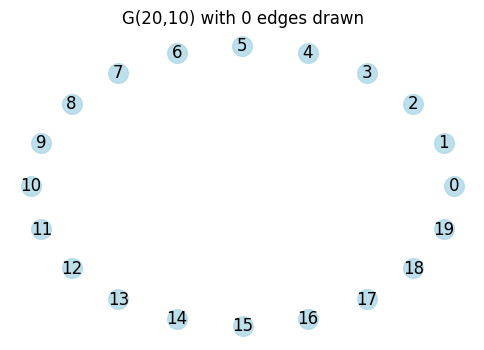

''

<Figure size 640x480 with 0 Axes>

In [4]:
############
## Cell 1 ##
############
import networkx as nx

G: nx.Graph = nx.Graph()
n: int = 20 
m: int = 10
G.add_nodes_from(range(0,n))
pos = nx.circular_layout(G)
edges_added: int = 0
title = f"G({n},{m}) with {edges_added} edges drawn"
update_plot(G, pos, set(G.nodes()), set(), title = title)


Add edges randomly by picking two nodes at random and seeing if 
- the two nodes are the same
- there is already an edge between the two nodes

If neither of those conditions hold, add the edge to the graph.

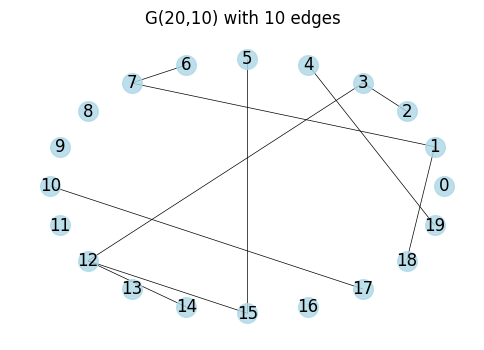

<Figure size 640x480 with 0 Axes>

In [5]:
############
## Cell 2 ##
############

import random

# Change this value
m = 10

while edges_added < m:
    while True:
        node1 = random.randint(0,n-1)
        node2 = random.randint(0,n-1)
        if node1 == node2: 
            continue
        if (node1,node2) not in set(G.edges):
            G.add_edge(node1,node2)
            break
    edges_added += 1
    title = f"G({n},{m}) with {edges_added} edges"
    update_plot(G, pos, set(G.nodes()), set(G.edges()), title = title)
    

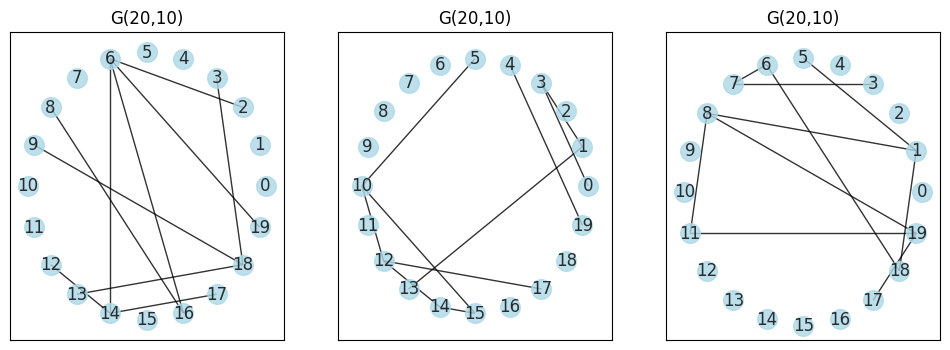

In [6]:
############
## Cell 3 ##
############

n = 20
m = 10
plt.figure(figsize = (12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    G: nx.Graph = nx.Graph()
    G.add_nodes_from(range(0,n))
    
    pos = nx.circular_layout(G)
    edges_added = 0
    while edges_added < m:
        while True:
            node1 = random.randint(0,n-1)
            node2 = random.randint(0,n-1)
            if node1 == node2: 
                continue
            if (node1,node2) not in set(G.edges):
                G.add_edge(node1,node2)
                break
        edges_added += 1
    ax = plt.gca()
    nx.draw_networkx(G,pos,node_color = 'lightblue', node_size = 200, alpha=0.8, with_labels = True)
    title = f"G({n},{m})"
    ax.set_title(title)
    

---

__G(n,p)__

This random graph model is harder to understand but easier to analyze. The model has two parameters:
- $n$ is the number of nodes
- $p$ is the probability that any two nodes will be connected.

Let's look at an animation of the process so that we can visually contrast it to the previous model

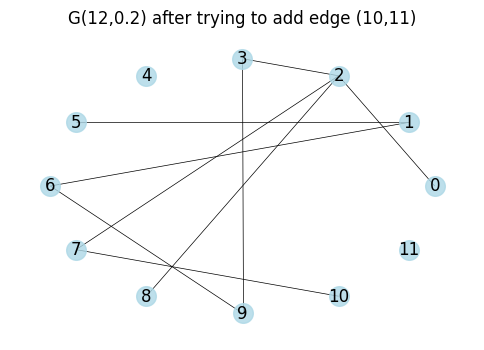

<Figure size 640x480 with 0 Axes>

In [7]:
############
## Cell 4 ##
############
from itertools import combinations
import imageio # For saving GIFs


n = 12
p: float = 0.2
G: nx.Graph = nx.Graph()
G.add_nodes_from(range(0,n))
pos = nx.circular_layout(G)
edges_added: int = 0

# uncomment if you want to create a GIF
frames = []

for n1, n2 in combinations(G.nodes(), 2):
    if random.random() < p:
        G.add_edge(n1, n2)
        edges_added += 1
    title = f"G({n},{p}) after trying to add edge ({n1},{n2})"
    # uncomment if you want to create a GIF
    #filename = update_plot(G, pos, set(G.nodes()), set(G.edges()), title = title, create_gif=True)
    # comment if you don't want to create a GIF
    _ = update_plot(G, pos, set(G.nodes()), set(G.edges()), title = title, create_gif=False)

    # Uncomment if you want to create a GIF 
    #frames.append(imageio.imread(filename))
    
# Uncomment if you want to create a GIF
#imageio.mimsave('random_graph.gif', frames, fps=2)

In [15]:
############
## Cell 5 ##
############
from scipy.special import comb
def compute_probability(n: int, m: int, p:float) -> float:
    return p**m * ((1-p)**(comb(n,2)-m))
def show_probabilities(n: int, p: float, num_of_edges: list[int]):
    print(f"For p = {p} and n = {n}:")
    for m in num_of_edges:
        print(f"\tthe probability of a graph with {m} edges is {compute_probability(n,m,p):.2e}")

# Change n
n = 20
show_probabilities(n,0, [0,1,2,5,10])
show_probabilities(n,0.001, [0,1,2,5,10])

For p = 0 and n = 20:
	the probability of a graph with 0 edges is 1.00e+00
	the probability of a graph with 1 edges is 0.00e+00
	the probability of a graph with 2 edges is 0.00e+00
	the probability of a graph with 5 edges is 0.00e+00
	the probability of a graph with 10 edges is 0.00e+00
For p = 0.001 and n = 20:
	the probability of a graph with 0 edges is 8.27e-01
	the probability of a graph with 1 edges is 8.28e-04
	the probability of a graph with 2 edges is 8.29e-07
	the probability of a graph with 5 edges is 8.31e-16
	the probability of a graph with 10 edges is 8.35e-31


In [9]:
############
## Cell 6 ##
############
show_probabilities(20,0.01, [0,1,2,5,10])
show_probabilities(20,0.1, [0,1,2,5,10])
show_probabilities(20,0.5, [0,1,2,5,10])
show_probabilities(20,0.8, [0,1,2,5,10])

For p = 0.01:
	the probability of a graph with 0 edges is 1.48e-01
	the probability of a graph with 1 edges is 1.50e-03
	the probability of a graph with 2 edges is 1.51e-05
	the probability of a graph with 5 edges is 1.56e-11
	the probability of a graph with 10 edges is 1.64e-21
For p = 0.1:
	the probability of a graph with 0 edges is 2.02e-09
	the probability of a graph with 1 edges is 2.25e-10
	the probability of a graph with 2 edges is 2.50e-11
	the probability of a graph with 5 edges is 3.43e-14
	the probability of a graph with 10 edges is 5.80e-19
For p = 0.5:
	the probability of a graph with 0 edges is 6.37e-58
	the probability of a graph with 1 edges is 6.37e-58
	the probability of a graph with 2 edges is 6.37e-58
	the probability of a graph with 5 edges is 6.37e-58
	the probability of a graph with 10 edges is 6.37e-58
For p = 0.8:
	the probability of a graph with 0 edges is 1.57e-133
	the probability of a graph with 1 edges is 6.28e-133
	the probability of a graph with 2 edges 

In [16]:
############
## Cell 7 ##
############
n = 20
p: float = 0.2
average_number_edges: float = comb(n,2) * p
print(f"Theoretical average number of edges is {average_number_edges:.2f}")
for i in range(5):
    G: nx.Graph = nx.erdos_renyi_graph(n,p)
    print(f"\tGraph {i} has {len(G.edges)} edges")
    del(G)

Theoretical average number of edges is 38.00
	Graph 0 has 38 edges
	Graph 1 has 40 edges
	Graph 2 has 36 edges
	Graph 3 has 41 edges
	Graph 4 has 43 edges


In [17]:
############
## Cell 8 ##
############
import numpy as np
n = 20
p = 0.2
m_average = comb(n,2) * p
print(f"Theoretical average degree is {np.round((n-1)*p,2)}")
for i in range(5):
    G: nx.Graph = nx.erdos_renyi_graph(n,p)
    degrees = [degree for node, degree in G.degree]
    print(f"\tGraph {i} has average degree {np.average(degrees)}")
    del(G)

Theoretical average degree is 3.8
	Graph 0 has average degree 4.1
	Graph 1 has average degree 3.8
	Graph 2 has average degree 3.8
	Graph 3 has average degree 3.7
	Graph 4 has average degree 3.3


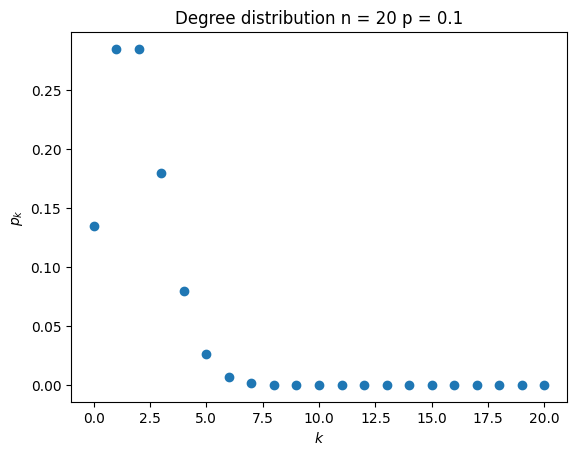

In [25]:
############
## Cell 9 ##
############
n = 20
p = 0.1
def p_k(n,k,p):
    return comb(n-1,k) *(p**k)* (1-p)**(n-1-k)
def show_histogram(n,p, use_subplot = False):
    k_values = []; p_values = []
    for k in range(0,n+1):
        k_values.append(k)
        p_values.append(p_k(n,k,p))
    if not use_subplot: 
        plt.figure()
    _ = plt.gca()
    plt.scatter(k_values,p_values)
    #ax.semilogy()
    plt.title('Degree distribution n = ' + str(n) + ' p = ' + str(p))
    plt.xlabel('$k$')
    plt.ylabel("$p_k$")
show_histogram(n,p)




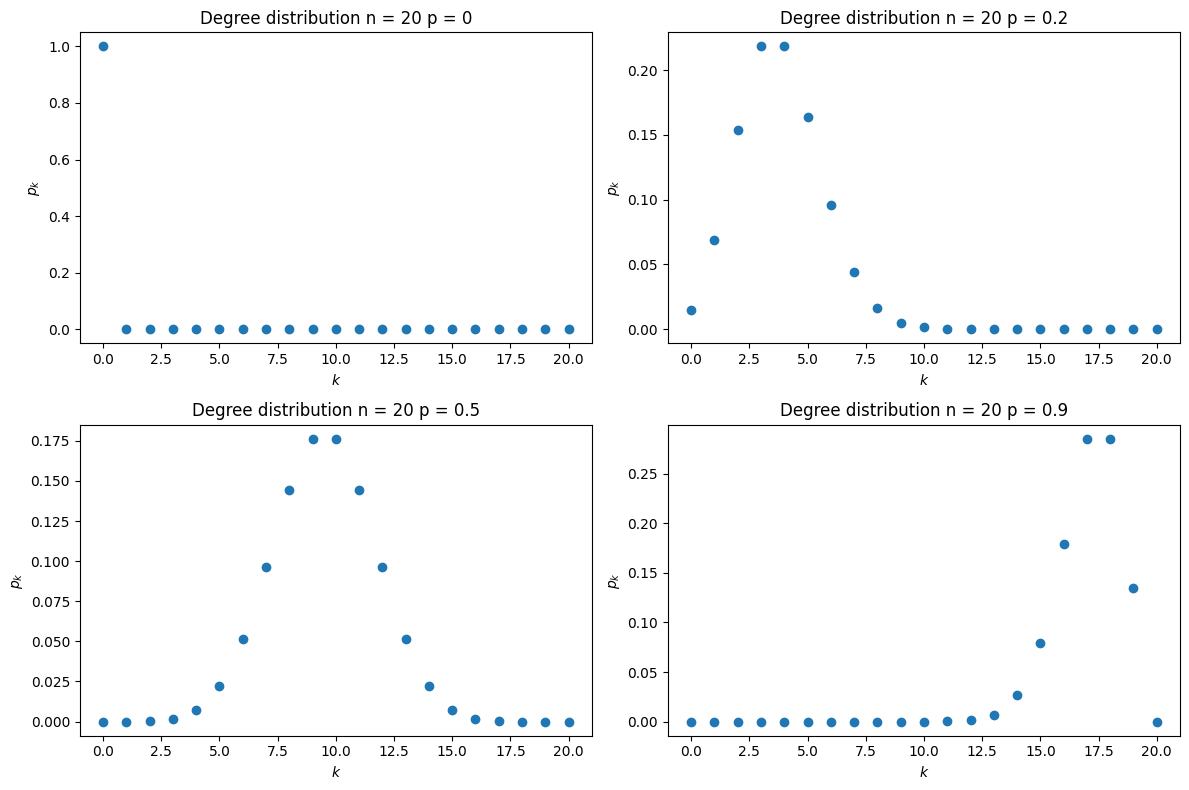

In [26]:
#############
## Cell 10 ##
#############
plt.figure(figsize=(12,8))
plt.subplot(221)
show_histogram(n,0, use_subplot=True)
plt.subplot(222)
show_histogram(n,0.2, use_subplot= True)
plt.subplot(223)
show_histogram(n,0.5, use_subplot= True)
plt.subplot(224)
show_histogram(n,0.9, use_subplot= True)
plt.tight_layout()

The emergence of a giant component as np increases

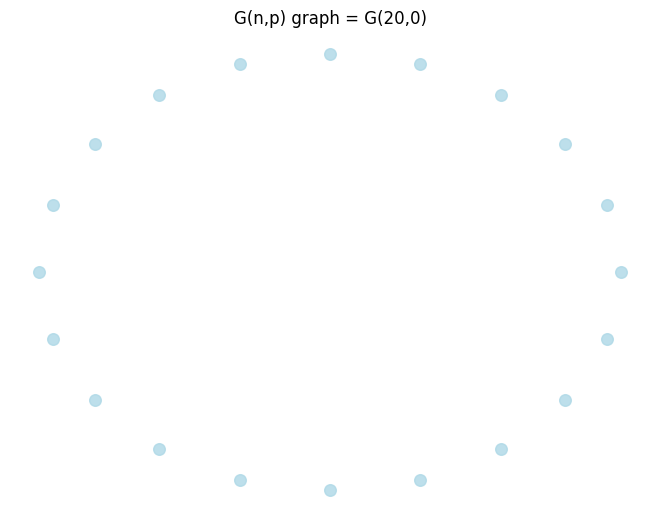

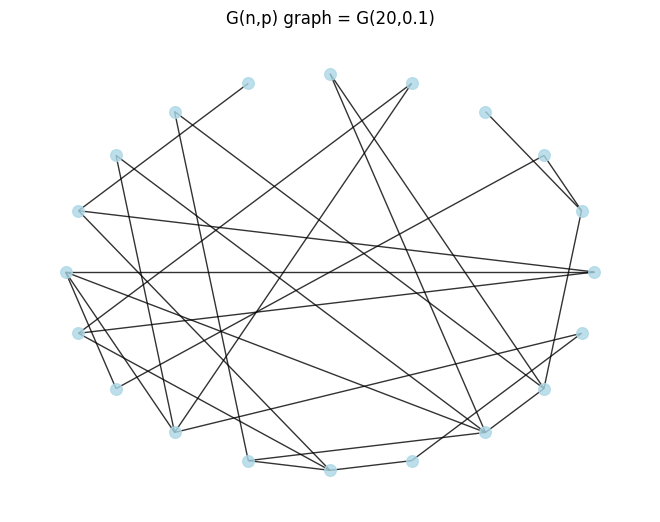

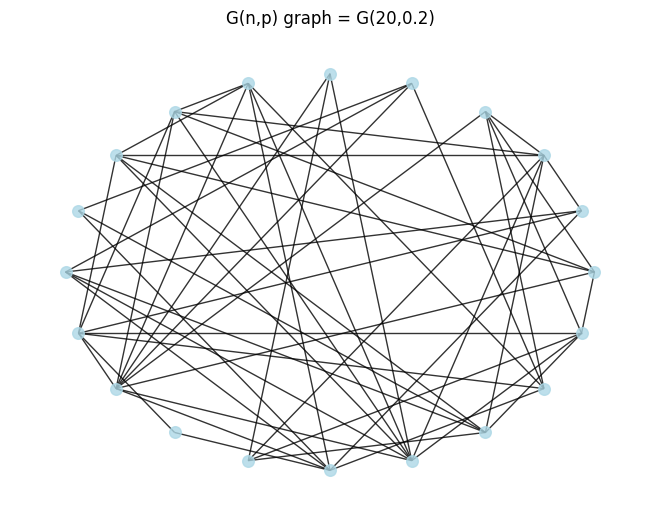

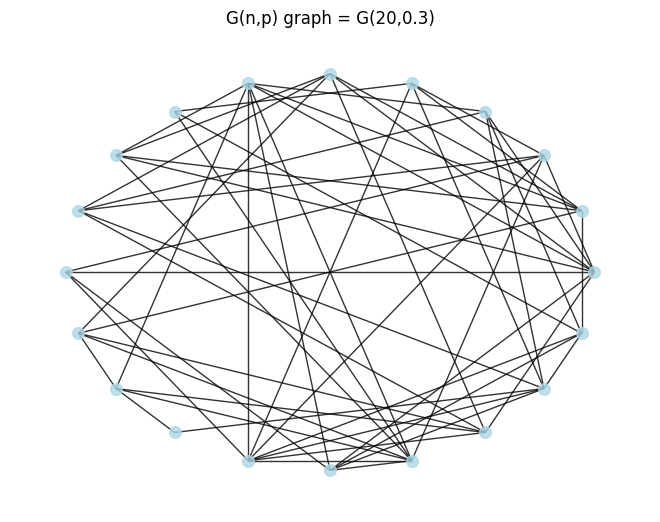

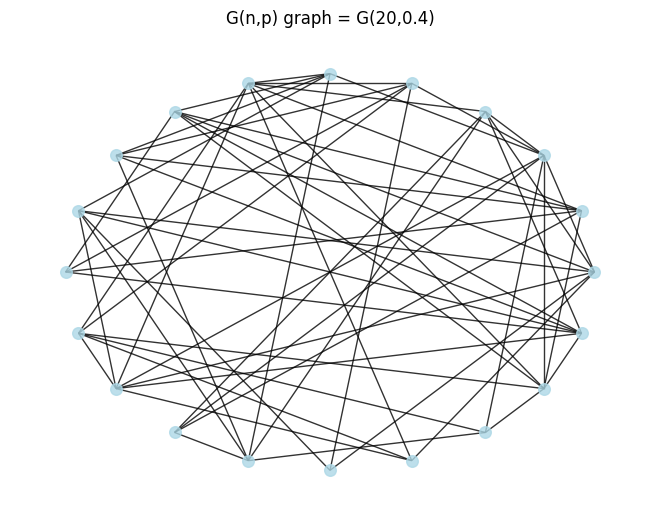

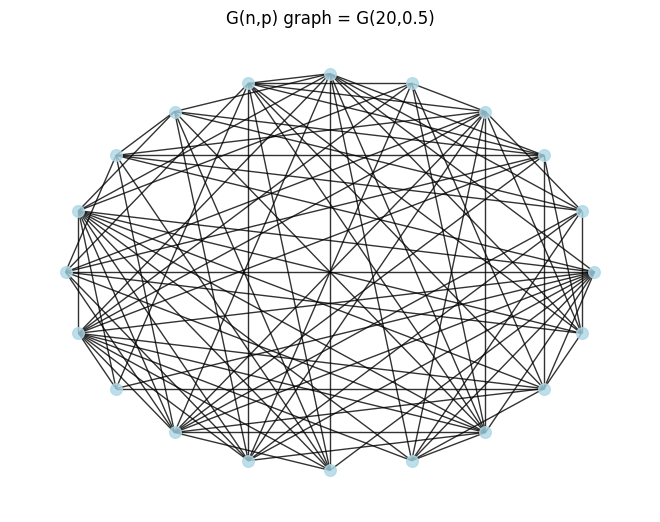

In [27]:
#############
## Cell 11 ##
#############
p = 0
n = 20
G: nx.Graph = nx.erdos_renyi_graph(n,p)
pos = nx.circular_layout(G)
while p <= 0.5:
    plt.figure()
    G: nx.Graph = nx.erdos_renyi_graph(n,p)
    plt.clf()
    nx.draw(G,pos,node_color = 'lightblue', node_size = 70, alpha=0.8)
    title = "G(n,p) graph = G("+str(n) + ","+str(np.round(p,2)) + ")"
    plt.title(title)
    p += 0.1

What does it mean to say that the size of the largest component grows in proportion to $n$?

Text(0, 0.5, 'size of largest component')

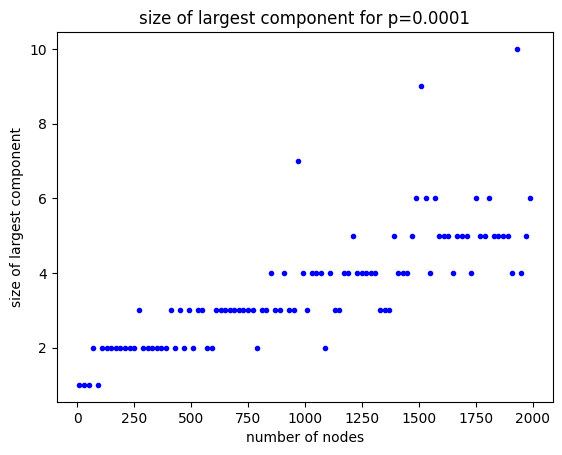

In [ ]:
###############
## Cell 12.a ##
###############
p = 0.01
num_nodes = range(10,2000,20)
component_size = []
for n in num_nodes:
    G: nx.Graph = nx.erdos_renyi_graph(n,p)
    largest_cc = max(nx.connected_components(G), key=len)
    component_size.append(len(largest_cc))
    #print(f"\tWhen n={n} the largest component has {component_size[-1]} nodes")
plt.plot(num_nodes,component_size,'b.')
plt.title(f"size of largest component for p={p}")
plt.xlabel("number of nodes")
plt.ylabel("size of largest component")


Text(0, 0.5, 'size of largest component / n')

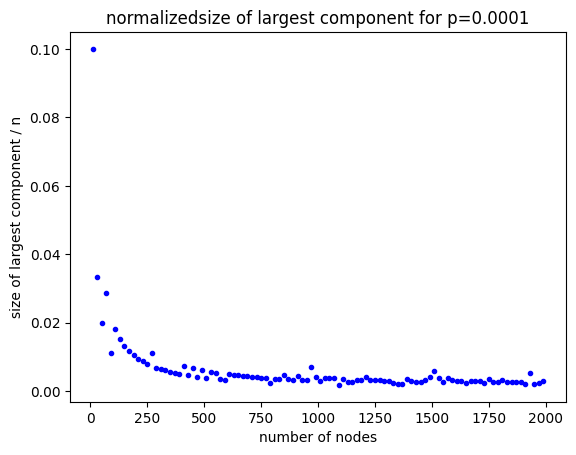

In [35]:
###############
## Cell 12.b ##
###############
plt.plot(num_nodes, [cs/n for cs, n in zip(component_size, num_nodes)], 'b.')
plt.title(f"normalizedsize of largest component for p={p}")
plt.xlabel("number of nodes")
plt.ylabel("size of largest component / n")

Text(0.5, 1.0, 'size of largest component for p=1e-06')

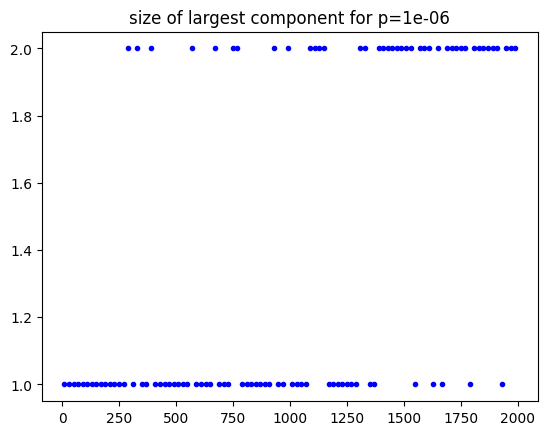

In [ ]:
#############
## Cell 13 ##
#############
p = 0.000001
num_nodes = range(10,2000,20)
component_size = []
for n in num_nodes:
    G = nx.erdos_renyi_graph(n,p)
    largest_cc = max(nx.connected_components(G), key=len)
    component_size.append(len(largest_cc))
    #print(f"\tWhen n={n} the largest component has {component_size[-1]} nodes")
plt.figure()
ax = plt.gca()
plt.plot(num_nodes,component_size,'b.')
ax.set_title(f"size of largest component for p={p}")


---

**Friendship Paradox:** Your friends are probably more popular than you.

In [ ]:
random.seed(0)
G: nx.Graph = nx.erdos_renyi_graph(1000,0.1)
for node in random.sample(list(G.nodes()), 6):
    print(f"Node {node} has degree {G.degree[node]}")
    print(f"The average degree of node {node}'s neighbors is {np.round(np.average([G.degree[neighbor] for neighbor in G.neighbors(node)]),2)}")

Node 968 has degree 94
The average degree of node 968's neighbors is 101.78
Node 146 has degree 95
The average degree of node 146's neighbors is 102.67
Node 711 has degree 97
The average degree of node 711's neighbors is 101.69
Node 838 has degree 105
The average degree of node 838's neighbors is 101.35
Node 329 has degree 90
The average degree of node 329's neighbors is 99.83
Node 15 has degree 100
The average degree of node 15's neighbors is 101.75


We'll see a proof of this property when we look at the configuration model.